# Atividade 01: Classificação - Notebook de Resposta

## Objetivo
Nesta atividade, vocês aplicarão os conceitos de mineração de dados para realizar uma classificação utilizando árvores de decisão. O objetivo é prever a sobrevivência dos passageiros do Titanic com base em informações como idade, gênero e classe do bilhete.
Serão avaliadas habilidades de leitura e tratamento de dados, visualização, seleção de atributos e avaliação de modelos.

**Os principais aspectos avaliados incluem:**
- Leitura e tratamento básico de dados
- Aplicação de técnicas de visualização
- Identificação e tratamento de atributos relevantes para classificação
- Avaliação das classificações geradas

## Cenário
O naufrágio do RMS Titanic é um dos desastres marítimos mais famosos da história. Muitos fatores influenciaram a sobrevivência dos passageiros, como classe social, gênero e idade. Nesta atividade, você utilizará um conjunto de dados real para prever se um passageiro sobreviveu ou não com base nessas informações.

---
## ⚠️ Orientações Importantes para o Preenchimento

1. Cada tarefa começa com um cabeçalho não editável (ex: “Tarefa 1. …”). O seu código e/ou o texto da sua resposta devem ficar **abaixo dessas células e acima do início** da próxima Tarefa.

1. Você **pode criar novas células** de código ou de texto Markdown abaixo do espaço sugerido, para separar bem suas subtarefas ou seu raciocínio. **Apenas garanta que elas fiquem contidas na respectiva região daquela tarefa**.

1. Você pode usar qualquer nível de título Markdown (“#”, “##”, listas, bullets, etc.) nas suas próprias células, se quiser organizar sua lógica.

1. **Não altere nem apague os enunciados!** As células que contêm as descrições das Tarefas estão protegidas para evitar a exclusão acidental; não as misture ao seu código.

---
## Tarefa 1. Leitura e Tratamento de Dados [2,0 pontos]
- Carregar o dataset "titanic.csv" com a biblioteca Pandas.
- Exibir informações gerais do dataset (quantidade de linhas e de colunas, tipos de dados, valores ausentes).
- Tratar valores ausentes, substituindo-os ou removendo-os de forma justificada.
- Codificar variáveis categóricas relevantes para facilitar a análise.


In [5]:
# from google.colab import files
# uploaded = files.upload()
import pandas as pd
import numpy as np

df_titanic = pd.read_csv('titanic.csv')

print("\nPrimeiras 5 linhas do dataset:")
print(df_titanic.head())

# Exibir informações gerais do dataset
print("Informações gerais do dataset:")
df_titanic.info()


print("\nValores ausentes antes do tratamento:")
print(df_titanic.isnull().sum())

df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0])
df_titanic.drop('Cabin', axis=1, inplace=True)

print("\nValores ausentes após o tratamento:")
print(df_titanic.isnull().sum())

df_titanic = pd.get_dummies(df_titanic, columns=['Sex', 'Embarked'], drop_first=True)

print("\nPrimeiras 5 linhas do dataset após tratamento e codificação:")
print(df_titanic.head())

print("\nTipos de dados após codificação:")
print(df_titanic.dtypes)



Primeiras 5 linhas do dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373

---
## Tarefa 2. Visualização dos Dados [2,0 pontos]
- Criar um histograma ou um boxplot para visualizar a distribuição de idades.
- Criar um gráfico de barras para analisar a relação entre o gênero e a sobrevivência.
- Criar um gráfico de dispersão ou um violin plot para avaliar a influência da tarifa paga sobre a sobrevivência.


/tmp/ipykernel_8670/3605649374.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex_male', y='Survived', data=df_titanic, ci=None)


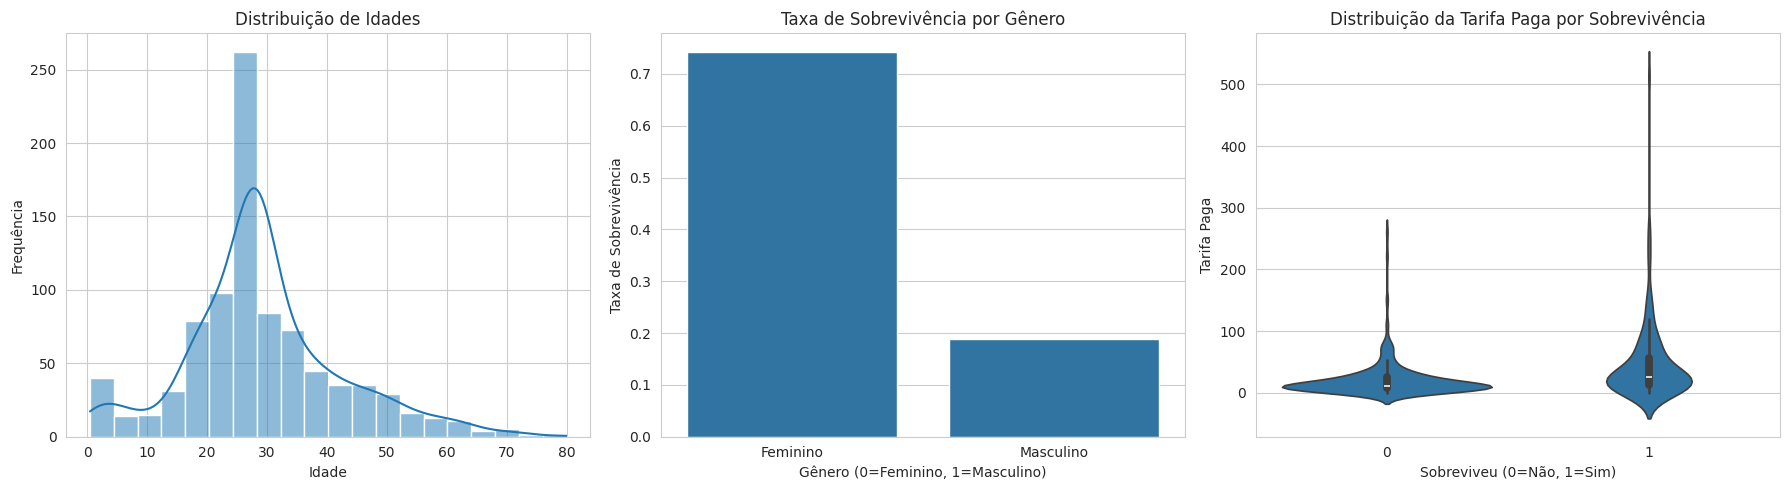

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhorar a visualização dos gráficos
sns.set_style("whitegrid")
plt.figure(figsize=(18, 5))

# Histograma para visualizar a distribuição de idades
plt.subplot(1, 3, 1)
sns.histplot(df_titanic['Age'], bins=20, kde=True)
plt.title('Distribuição de Idades')
plt.xlabel('Idade')
plt.ylabel('Frequência')

# Gráfico de barras para analisar a relação entre o gênero e a sobrevivência
plt.subplot(1, 3, 2)
sns.barplot(x='Sex_male', y='Survived', data=df_titanic, ci=None)
plt.title('Taxa de Sobrevivência por Gênero')
plt.xlabel('Gênero (0=Feminino, 1=Masculino)')
plt.ylabel('Taxa de Sobrevivência')
plt.xticks(ticks=[0, 1], labels=['Feminino', 'Masculino'])

# Violin plot para avaliar a influência da tarifa paga sobre a sobrevivência
plt.subplot(1, 3, 3)
sns.violinplot(x='Survived', y='Fare', data=df_titanic)
plt.title('Distribuição da Tarifa Paga por Sobrevivência')
plt.xlabel('Sobreviveu (0=Não, 1=Sim)')
plt.ylabel('Tarifa Paga')

plt.tight_layout()
plt.show()


---
## Tarefa 3. Tratamento e Seleção de Dados para Classificação [3,0 pontos]
- Selecionar atributos relevantes para a classificação, evitando características/colunas que não contribuem para a previsão.
- Dividir os dados em conjuntos de treino (70%) e de teste (30%).
- Implementar árvores de decisão utilizando a biblioteca Scikit-Learn:
  - Testar diferentes critérios de geração
  - Testar diferentes níveis de profundidade
  - Averiguar quais configurações apresentam melhor ou pior desempenho, a ser analisado na Avaliação.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Selecionar atributos relevantes para a classificação
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
target = 'Survived'

X = df_titanic[features]
y = df_titanic[target]

# Dividir os dados em conjuntos de treino (70%) e de teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")

# Implementar árvores de decisão utilizando a biblioteca Scikit-Learn
# Testar diferentes critérios de geração e diferentes níveis de profundidade

criterions = ['gini', 'entropy']
max_depths = [3, 5, 7, 10, None]

models = {}
for criterion in criterions:
    for depth in max_depths:
        model_name = f"DecisionTree_Criterion-{criterion}_Depth-{depth}"
        print(f"\nTreinando modelo: {model_name}")

        dt_classifier = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        dt_classifier.fit(X_train, y_train)
        models[model_name] = dt_classifier

        # Averiguar quais configurações apresentam melhor ou pior desempenho
        y_pred = dt_classifier.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Acurácia no conjunto de teste para {model_name}: {accuracy:.4f}")


Tamanho do conjunto de treino: 623 amostras
Tamanho do conjunto de teste: 268 amostras

Treinando modelo: DecisionTree_Criterion-gini_Depth-3
Acurácia no conjunto de teste para DecisionTree_Criterion-gini_Depth-3: 0.8097

Treinando modelo: DecisionTree_Criterion-gini_Depth-5
Acurácia no conjunto de teste para DecisionTree_Criterion-gini_Depth-5: 0.7948

Treinando modelo: DecisionTree_Criterion-gini_Depth-7
Acurácia no conjunto de teste para DecisionTree_Criterion-gini_Depth-7: 0.7799

Treinando modelo: DecisionTree_Criterion-gini_Depth-10
Acurácia no conjunto de teste para DecisionTree_Criterion-gini_Depth-10: 0.7799

Treinando modelo: DecisionTree_Criterion-gini_Depth-None
Acurácia no conjunto de teste para DecisionTree_Criterion-gini_Depth-None: 0.7463

Treinando modelo: DecisionTree_Criterion-entropy_Depth-3
Acurácia no conjunto de teste para DecisionTree_Criterion-entropy_Depth-3: 0.8097

Treinando modelo: DecisionTree_Criterion-entropy_Depth-5
Acurácia no conjunto de teste para De

---
## Tarefa 4. Avaliação das Classificações Obtidas [3,0 pontos]
- Gerar a matriz de confusão de cada modelo gerado.
- Calcular e interpretar as métricas de Accuracy, Precision, Recall, F1-Score e ROC/AUC para cada modelo gerado.

### Discussão
- Discutir os resultados obtidos e sugerir melhorias nos modelos.
  - Qual foi o melhor? Com quais parâmetros? De forma análoga, qual foi o melhor?


--- Avaliação do Modelo: DecisionTree_Criterion-gini_Depth-3 ---


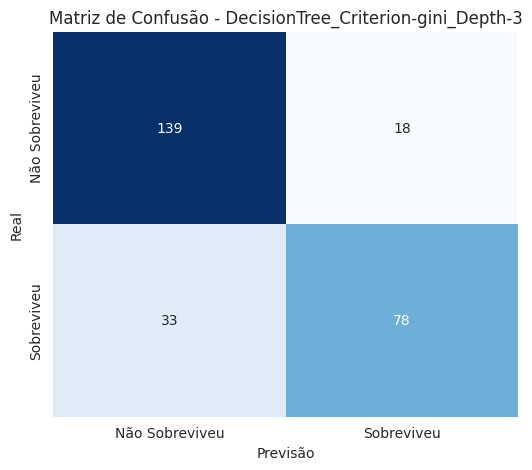

Métricas de Desempenho:
  Accuracy: 0.8097
  Precision: 0.8125
  Recall: 0.7027
  F1-Score: 0.7536
  ROC-AUC: 0.8203


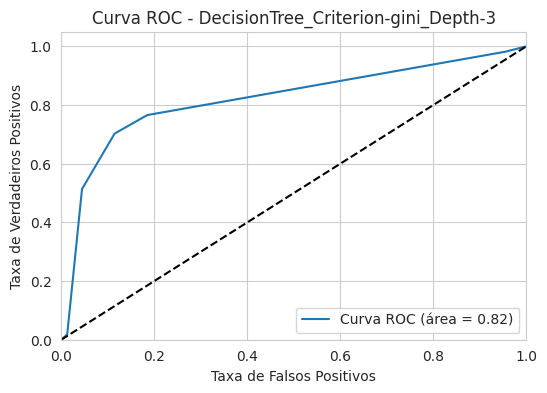


--- Avaliação do Modelo: DecisionTree_Criterion-gini_Depth-5 ---


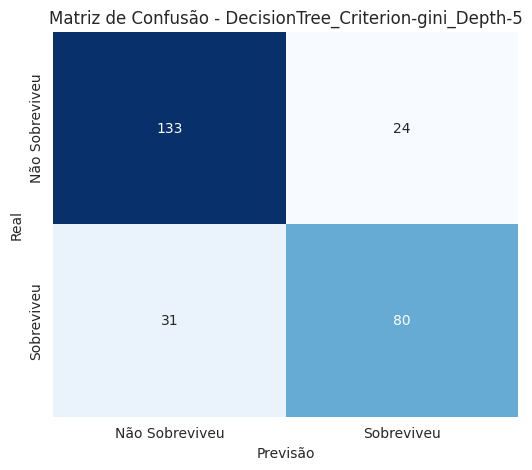

Métricas de Desempenho:
  Accuracy: 0.7948
  Precision: 0.7692
  Recall: 0.7207
  F1-Score: 0.7442
  ROC-AUC: 0.8219


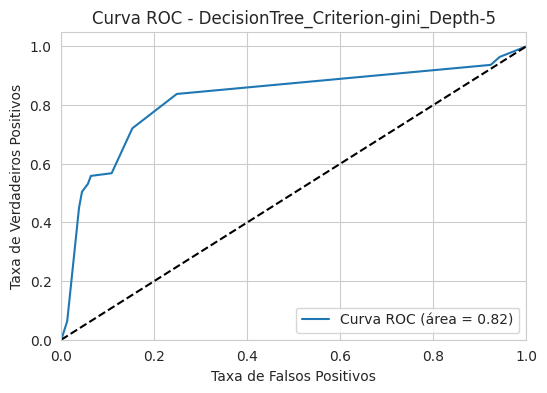


--- Avaliação do Modelo: DecisionTree_Criterion-gini_Depth-7 ---


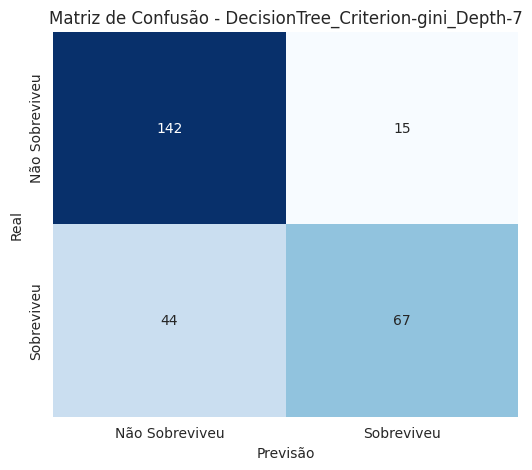

Métricas de Desempenho:
  Accuracy: 0.7799
  Precision: 0.8171
  Recall: 0.6036
  F1-Score: 0.6943
  ROC-AUC: 0.7903


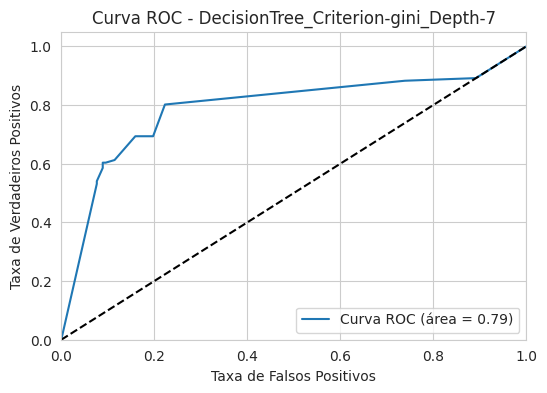


--- Avaliação do Modelo: DecisionTree_Criterion-gini_Depth-10 ---


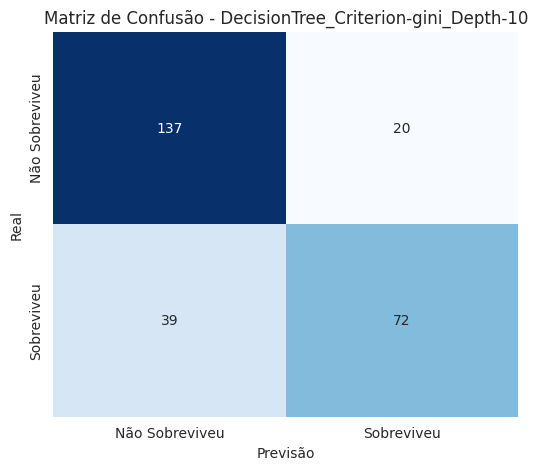

Métricas de Desempenho:
  Accuracy: 0.7799
  Precision: 0.7826
  Recall: 0.6486
  F1-Score: 0.7094
  ROC-AUC: 0.7469


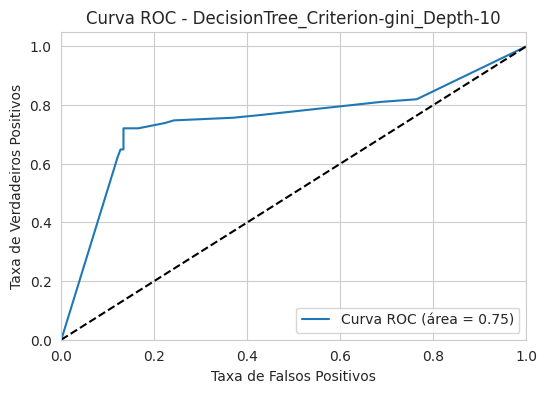


--- Avaliação do Modelo: DecisionTree_Criterion-gini_Depth-None ---


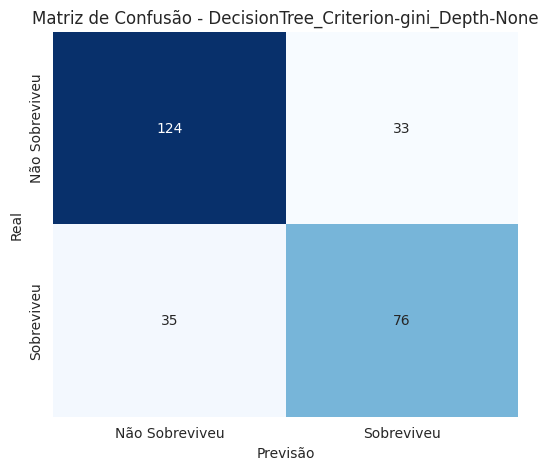

Métricas de Desempenho:
  Accuracy: 0.7463
  Precision: 0.6972
  Recall: 0.6847
  F1-Score: 0.6909
  ROC-AUC: 0.7347


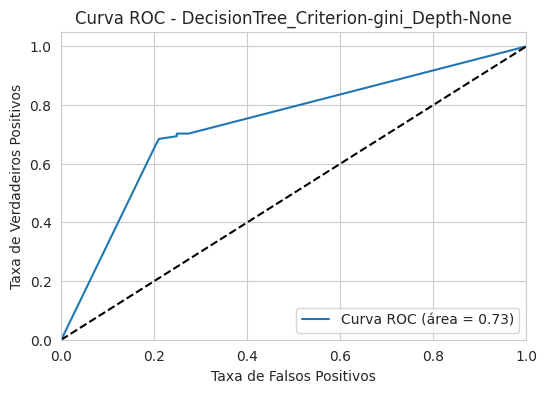


--- Avaliação do Modelo: DecisionTree_Criterion-entropy_Depth-3 ---


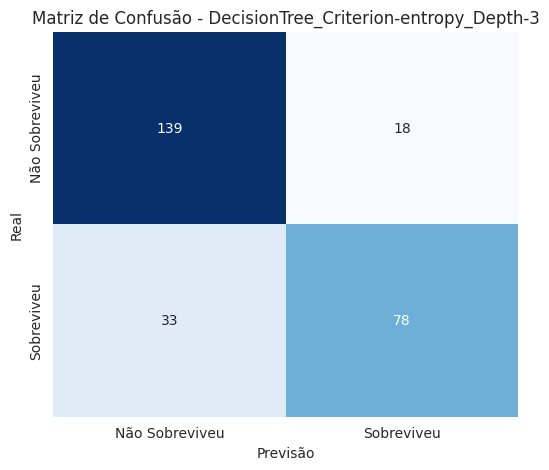

Métricas de Desempenho:
  Accuracy: 0.8097
  Precision: 0.8125
  Recall: 0.7027
  F1-Score: 0.7536
  ROC-AUC: 0.8553


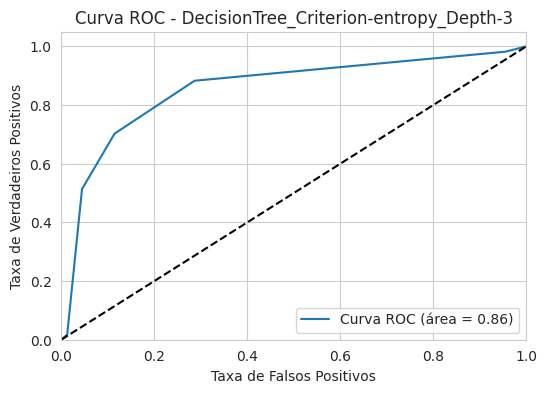


--- Avaliação do Modelo: DecisionTree_Criterion-entropy_Depth-5 ---


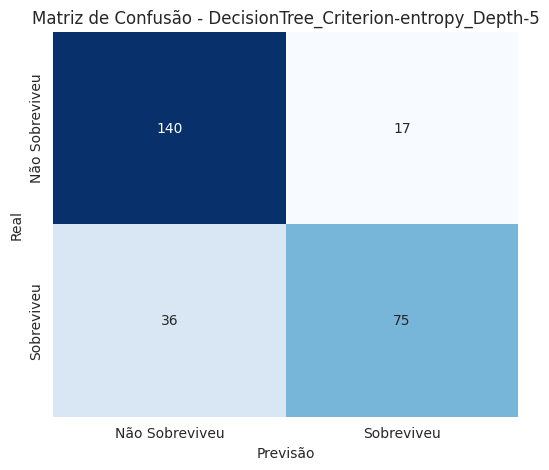

Métricas de Desempenho:
  Accuracy: 0.8022
  Precision: 0.8152
  Recall: 0.6757
  F1-Score: 0.7389
  ROC-AUC: 0.8433


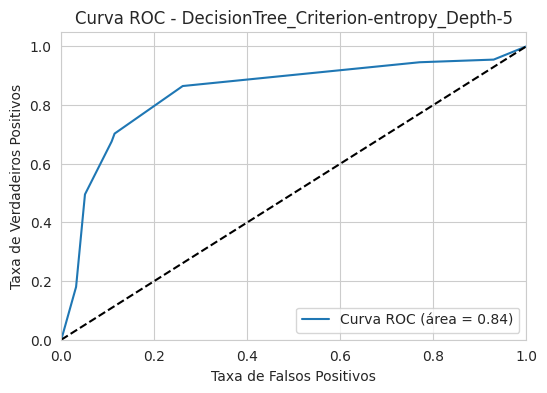


--- Avaliação do Modelo: DecisionTree_Criterion-entropy_Depth-7 ---


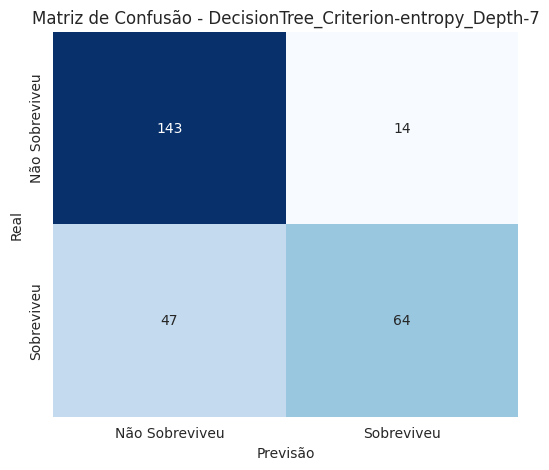

Métricas de Desempenho:
  Accuracy: 0.7724
  Precision: 0.8205
  Recall: 0.5766
  F1-Score: 0.6772
  ROC-AUC: 0.8228


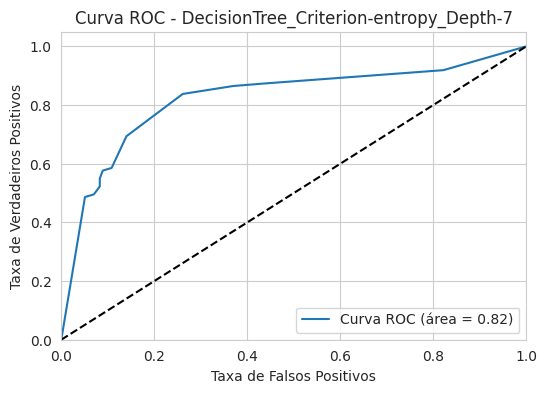


--- Avaliação do Modelo: DecisionTree_Criterion-entropy_Depth-10 ---


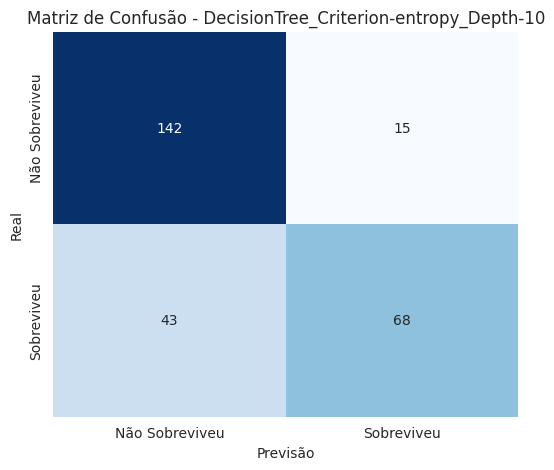

Métricas de Desempenho:
  Accuracy: 0.7836
  Precision: 0.8193
  Recall: 0.6126
  F1-Score: 0.7010
  ROC-AUC: 0.7637


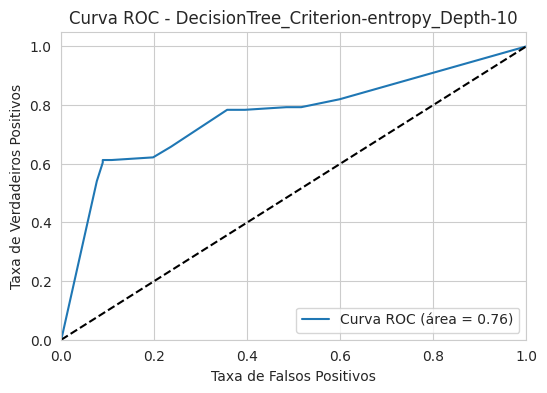


--- Avaliação do Modelo: DecisionTree_Criterion-entropy_Depth-None ---


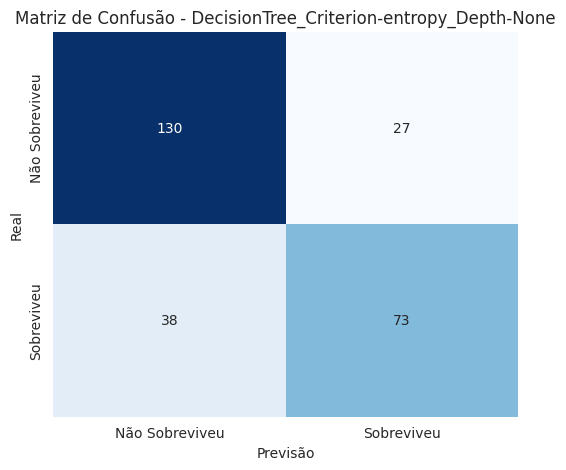

Métricas de Desempenho:
  Accuracy: 0.7575
  Precision: 0.7300
  Recall: 0.6577
  F1-Score: 0.6919
  ROC-AUC: 0.7411


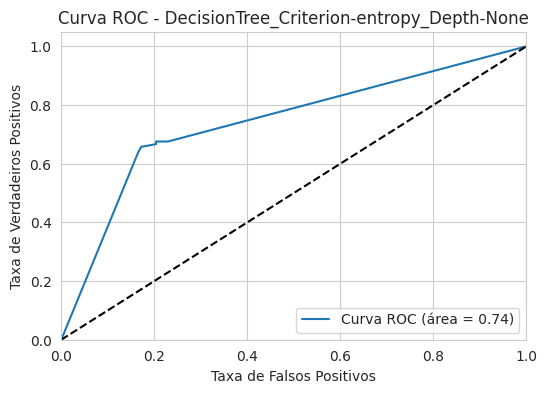


--- Resumo Comparativo dos Modelos ---

Modelo: DecisionTree_Criterion-gini_Depth-3
  Accuracy: 0.8097
  Precision: 0.8125
  Recall: 0.7027
  F1-Score: 0.7536
  ROC-AUC: 0.8203

Modelo: DecisionTree_Criterion-gini_Depth-5
  Accuracy: 0.7948
  Precision: 0.7692
  Recall: 0.7207
  F1-Score: 0.7442
  ROC-AUC: 0.8219

Modelo: DecisionTree_Criterion-gini_Depth-7
  Accuracy: 0.7799
  Precision: 0.8171
  Recall: 0.6036
  F1-Score: 0.6943
  ROC-AUC: 0.7903

Modelo: DecisionTree_Criterion-gini_Depth-10
  Accuracy: 0.7799
  Precision: 0.7826
  Recall: 0.6486
  F1-Score: 0.7094
  ROC-AUC: 0.7469

Modelo: DecisionTree_Criterion-gini_Depth-None
  Accuracy: 0.7463
  Precision: 0.6972
  Recall: 0.6847
  F1-Score: 0.6909
  ROC-AUC: 0.7347

Modelo: DecisionTree_Criterion-entropy_Depth-3
  Accuracy: 0.8097
  Precision: 0.8125
  Recall: 0.7027
  F1-Score: 0.7536
  ROC-AUC: 0.8553

Modelo: DecisionTree_Criterion-entropy_Depth-5
  Accuracy: 0.8022
  Precision: 0.8152
  Recall: 0.6757
  F1-Score: 0.7389
  

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


results = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probabilidades para a classe positiva (sobreviveu)

    # Gerar a matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    # Calcular as métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[model_name] = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    print(f"\n--- Avaliação do Modelo: {model_name} ---")

    # Melhorar a apresentação da matriz de confusão com seaborn
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Não Sobreviveu', 'Sobreviveu'],
                yticklabels=['Não Sobreviveu', 'Sobreviveu'])
    plt.xlabel('Previsão')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusão - {model_name}')
    plt.show()

    # Apresentar as métricas logo abaixo da matriz
    print("Métricas de Desempenho:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

    # Plotar a curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'Curva ROC (área = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title(f'Curva ROC - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

# Discussão dos resultados (mantida para o final, como um resumo)
best_model_name = None
best_roc_auc = -1

print("\n--- Resumo Comparativo dos Modelos ---")
for model_name, metrics in results.items():
    print(f"\nModelo: {model_name}")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall: {metrics['Recall']:.4f}")
    print(f"  F1-Score: {metrics['F1-Score']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")

    if metrics['ROC-AUC'] > best_roc_auc:
        best_roc_auc = metrics['ROC-AUC']
        best_model_name = model_name

print(f"\nO melhor modelo, com base no ROC-AUC, foi: {best_model_name} com ROC-AUC de {best_roc_auc:.4f}")

# Análise dos Resultados

Com base nos resultados apresentados, o melhor modelo, com base no ROC-AUC, foi o **DecisionTree_Criterion-entropy_Depth-3**, que alcançou um ROC-AUC de **0.8553**. Este modelo também demonstrou um bom equilíbrio entre as outras métricas: Accuracy de 0.8097, Precision de 0.8125, Recall de 0.7027 e F1-Score de 0.7536. A profundidade de 3, combinada com o critério '*entropy*', parece ter sido o ponto ideal para este conjunto de dados, permitindo que a árvore capturasse padrões relevantes sem se tornar excessivamente complexa e propensa a overfitting.

É interessante notar que, embora uma profundidade maior, como Depth-5 ou Depth-7 com '*entropy*', tenha sido testada, elas resultaram em ROC-AUCs ligeiramente menores: 0.8433 e 0.8228, respectivamente, indicando que, para este problema, uma árvore mais "rasa" e menos complexa com o critério de entropia foi mais eficaz na generalização. Modelos com profundidade ilimitada, max_depth=None, ou muito alta (max_depth=10) geralmente apresentaram desempenho inferior, confirmando o risco de sobreajuste.

